---
# Dataset Download

This project uses the **ISOT Fake and Real News Dataset** from Kaggle: two CSV files, `True.csv` (Reuters-sourced real articles) and `Fake.csv` (articles from sources flagged as unreliable), together comprising roughly 44,000 news articles.

**Why this dataset:** it's large enough for classical ML to train reliably, close to class-balanced, and widely used in prior published research, so results here are comparable to established benchmarks rather than evaluated in isolation.


## Option A: Download via the Kaggle API 


In [1]:
import os

os.makedirs('../dataset', exist_ok=True)

# Downloads True.csv and Fake.csv directly into ../dataset/
# (requires kaggle.json to be configured as described above)
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset -p ../dataset --unzip

print("Files in dataset/:", os.listdir('../dataset'))


Files in dataset/: ['cleaned_news.csv', 'w2v_document_vectors.npy', 'X_test_tfidf.npz', 'X_test_w2v.npy', 'X_train_tfidf.npz', 'X_train_w2v.npy', 'y_test.npy', 'y_train.npy']


'kaggle' is not recognized as an internal or external command,
operable program or batch file.


## Option B: Manual Download

In [2]:
import os

import pandas as pd

# Sanity check: confirm both files are present and readable before proceeding
true_check = pd.read_csv('../datasets/True.csv')
fake_check = pd.read_csv('../datasets/Fake.csv')
print(f"True.csv:  {true_check.shape[0]} rows, columns = {list(true_check.columns)}")
print(f"Fake.csv:  {fake_check.shape[0]} rows, columns = {list(fake_check.columns)}")
del true_check, fake_check  # full loading with labels happens in Phase 1 below


True.csv:  21417 rows, columns = ['title', 'text', 'subject', 'date']
Fake.csv:  23481 rows, columns = ['title', 'text', 'subject', 'date']


---
# Phase 1 — Exploratory Data Analysis

## 1. Imports

We load pandas for data handling, matplotlib/seaborn for plotting, nltk for tokenization and stopwords, and `Counter` for frequency counting. `%matplotlib inline` ensures plots render directly in the notebook.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from wordcloud import WordCloud

# Download required NLTK resources (only needs to run once per environment)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
STOPWORDS = set(stopwords.words('english'))


## 2. Load and Merge the Dataset

Why we do this: the raw data ships as two separate files with no label column. We load both, tag each with a `label`, and concatenate them into a single DataFrame so every later step (cleaning, feature extraction, modeling) works on one unified table.

**Common mistake:** forgetting to shuffle after concatenation — if you don't shuffle, all fake articles come before all real articles, which can bite you later if you ever do a naive sequential train/test split instead of `train_test_split(..., stratify=y)`.


In [ ]:
true_df = pd.read_csv('../datasets/True.csv')
fake_df = pd.read_csv('../datasets/Fake.csv')

true_df['label'] = 1  # 1 = real
fake_df['label'] = 0  # 0 = fake

df = pd.concat([true_df, fake_df], axis=0, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"Total articles: {len(df)}")
df.head()


Total articles: 44898


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


## 3. Dataset Shape, Structure, and Info

**Why we do this:** before touching the text, confirm the dataset actually looks like what we expect — the right number of rows, the right columns, and sensible dtypes. `df.info()` also reveals non-null counts per column, giving a first pass at missing data.


In [ ]:
print("Shape (rows, columns):", df.shape)
print()
df.info()


Shape (rows, columns): (44898, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [ ]:
df.describe(include='object')


,title,text,subject,date
count,44898,44898,44898,44898
unique,38729,38646,8,2397
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017"
freq,14,627,11272,182


## 4. Missing Values and Duplicates

Missing text fields would break tokenization downstream, and duplicate articles (a known quirk of scraped news datasets) can leak between train and test splits, inflating reported accuracy. Both need to be resolved before EDA statistics like word count are trustworthy.

**Expected output:** the ISOT dataset is generally clean, but always verify rather than assume — datasets get re-uploaded and re-packaged over time and the exact numbers can drift.


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated on 'text' only:", df.duplicated(subset=['text']).sum())


Missing values per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Fully duplicated rows: 209
Duplicated on 'text' only: 6252


In [ ]:
# Drop exact duplicate rows and duplicate article bodies, keeping the first occurrence
before = len(df)
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate articles — {len(df)} remain")


Removed 6252 duplicate articles — 38646 remain


## 5. Class Distribution

A large imbalance between real and fake articles would mean accuracy alone is a misleading metric, and would push us toward class-weighted models or resampling. Plotting it up front sets expectations for every metric we report later.


label
Real    21191
Fake    17455
Name: count, dtype: int64

Class balance (%):
label
Real    54.83
Fake    45.17
Name: count, dtype: float64


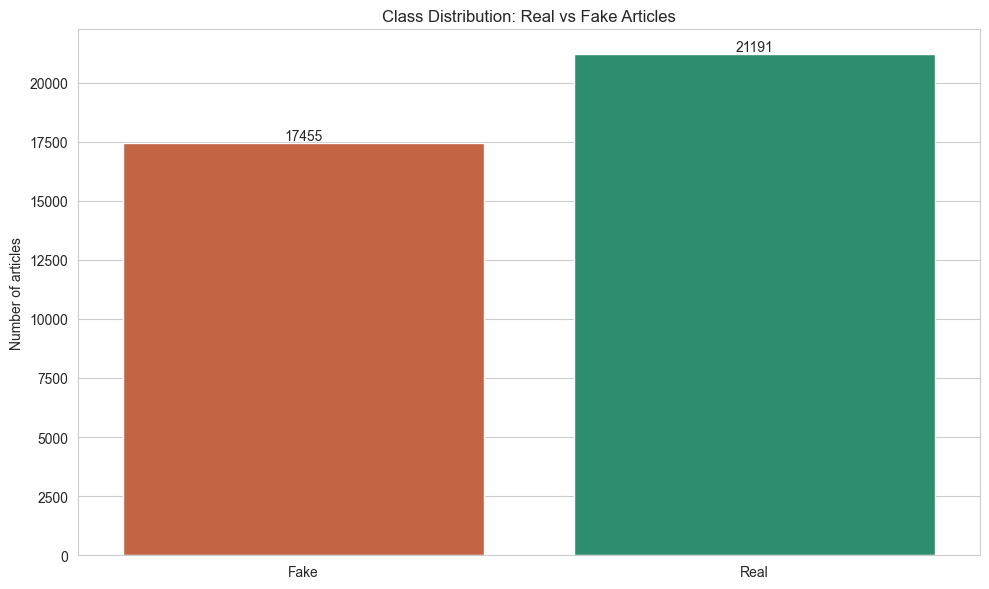

In [ ]:
label_counts = df['label'].value_counts().rename({0: 'Fake', 1: 'Real'})
print(label_counts)
print()
print("Class balance (%):")
print((label_counts / len(df) * 100).round(2))

ax = sns.countplot(x=df['label'].map({0: 'Fake', 1: 'Real'}), hue=df['label'].map({0: 'Fake', 1: 'Real'}), palette=['#D85A30', '#1D9E75'], legend=False)
ax.set_title('Class Distribution: Real vs Fake Articles')
ax.set_xlabel('')
ax.set_ylabel('Number of articles')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=150)
plt.show()


**How to read this graph:** each bar is the raw count of articles in that class. If the bars are close in height (roughly within a 55/45 split), accuracy is a reasonably safe headline metric later; if they diverge a lot more than that, precision/recall/F1 should be weighted more heavily than accuracy when comparing models.


## 6. Text Length Analysis: Words, Characters, Sentences

Article length is one of the simplest, most robust signals separating real and fake news in this dataset — real Reuters wire articles tend to follow a fairly consistent structure and length, while fake articles vary much more widely. These derived columns will also matter later when deciding on reasonable sequence-length assumptions if you ever move to a neural model.


In [ ]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(lambda x: len(str(x)))
df['sentence_count'] = df['text'].apply(lambda x: len(sent_tokenize(str(x))))

df[['word_count', 'char_count', 'sentence_count']].describe()


,word_count,char_count,sentence_count
count,38646.000000,38646.000000,38646.000000
mean,403.089971,2455.888061,15.057470
std,313.828131,1936.609582,11.990948
min,0.000000,1.000000,0.000000
25%,216.000000,1318.000000,7.000000
50%,369.000000,2227.000000,13.000000
75%,511.000000,3096.000000,20.000000
max,8135.000000,51794.000000,321.000000


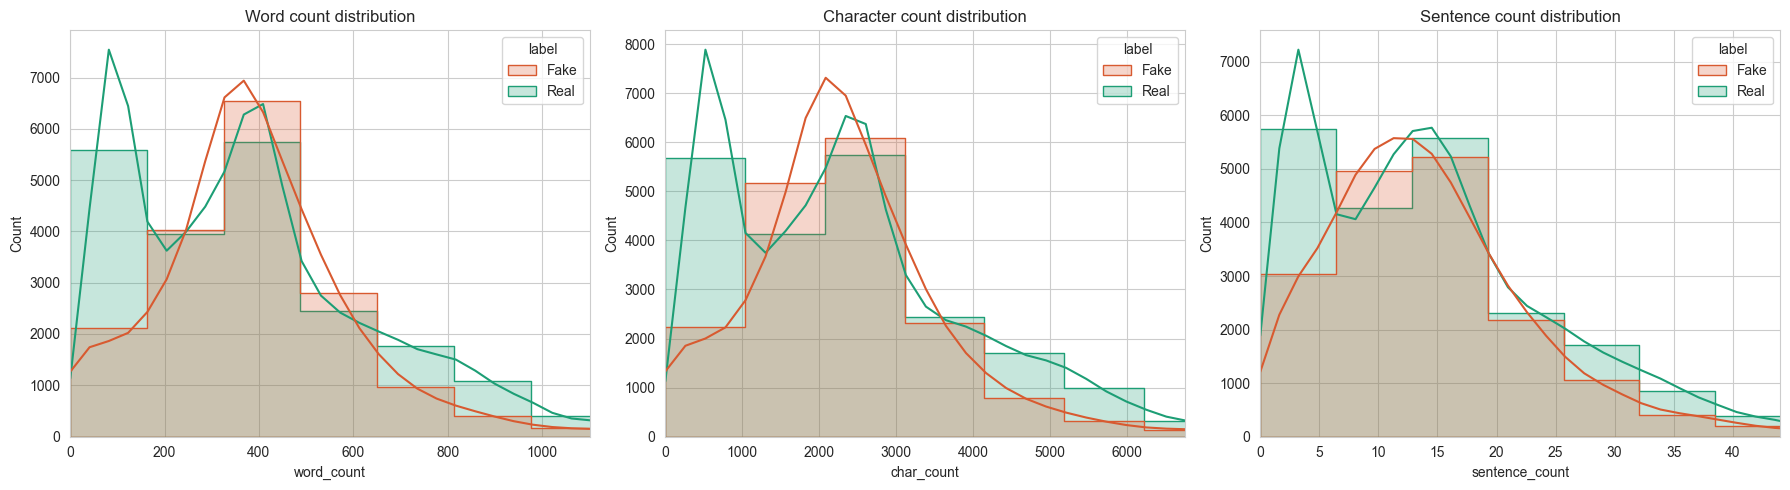

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('word_count', 'Word count'), ('char_count', 'Character count'), ('sentence_count', 'Sentence count')]

for ax, (col, title) in zip(axes, metrics):
    sns.histplot(data=df, x=col, hue=df['label'].map({0: 'Fake', 1: 'Real'}),
                 bins=50, kde=True, ax=ax, palette=['#D85A30', '#1D9E75'], element='step')
    ax.set_title(f'{title} distribution')
    ax.set_xlim(0, df[col].quantile(0.98))  # trim extreme outliers for readability

plt.tight_layout()
plt.savefig('../images/length_distributions.png', dpi=150)
plt.show()


Each panel overlays the real and fake distributions for one length metric. Look for separation between the two colored curves — if fake articles cluster at noticeably different lengths than real articles, that's a usable (if superficial) signal, and it also explains part of why even simple models tend to do well on this dataset. The x-axis is trimmed at the 98th percentile so a handful of extremely long outlier articles don't compress the rest of the histogram.


## 7. Vocabulary Analysis: Most and Least Frequent Words
This is where we get our first real look at *content*, not just structure. Comparing the top words in real vs. fake articles previews what TF-IDF will later pick up on automatically, and least-frequent words help gauge vocabulary noise (typos, rare proper nouns) that preprocessing should address.

> Stopwords are removed here specifically for this analysis so the frequent-word lists are meaningful — this does not modify the underlying dataset.


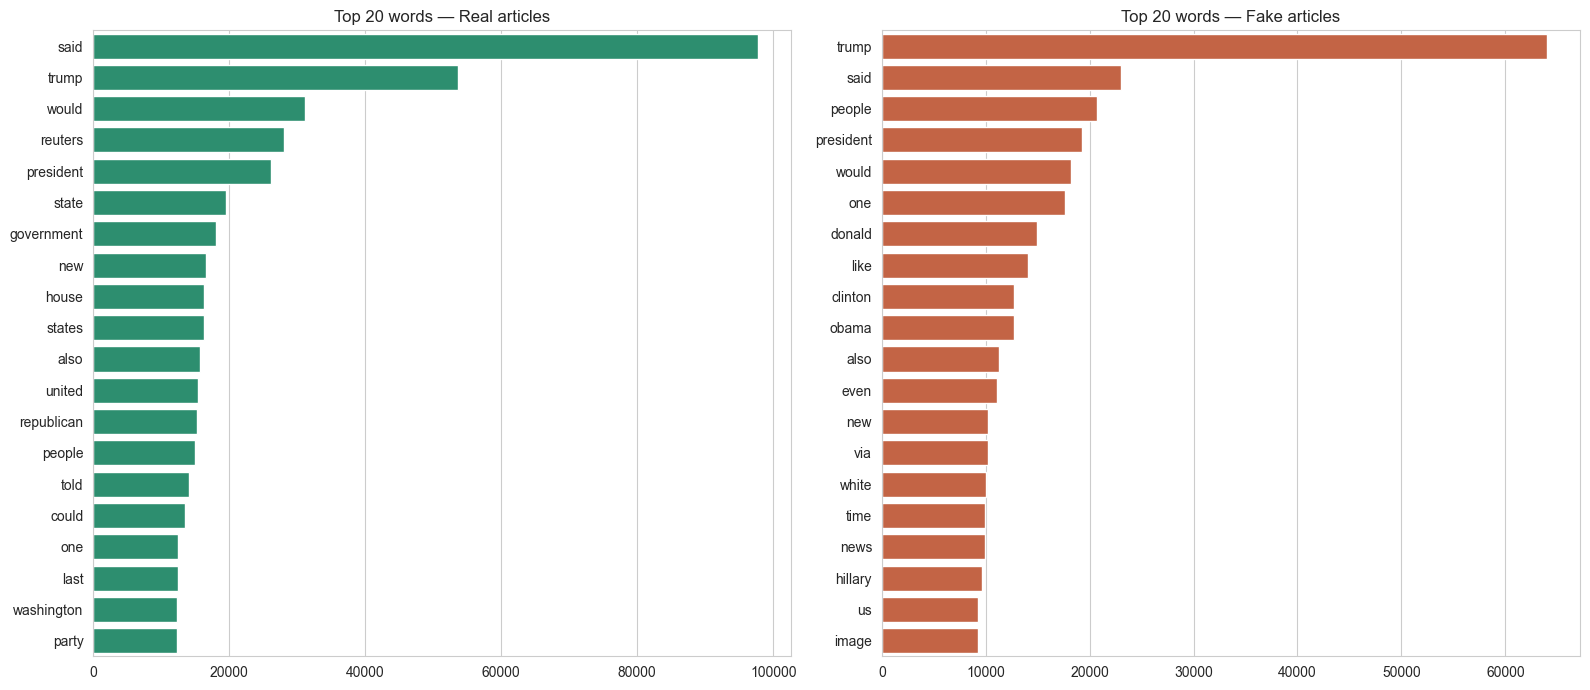

In [ ]:
def get_word_freq(text_series, top_n=20, most_common=True):
    all_words = []
    for text in text_series:
        tokens = word_tokenize(str(text).lower())
        tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS]
        all_words.extend(tokens)
    counter = Counter(all_words)
    return counter.most_common(top_n) if most_common else counter.most_common()[-top_n:]

real_top = get_word_freq(df[df['label'] == 1]['text'], top_n=20)
fake_top = get_word_freq(df[df['label'] == 0]['text'], top_n=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(x=[c for _, c in real_top], y=[w for w, _ in real_top], ax=axes[0], color='#1D9E75')
axes[0].set_title('Top 20 words — Real articles')
sns.barplot(x=[c for _, c in fake_top], y=[w for w, _ in fake_top], ax=axes[1], color='#D85A30')
axes[1].set_title('Top 20 words — Fake articles')
plt.tight_layout()
plt.savefig('../images/top_words_by_class.png', dpi=150)
plt.show()


Words appearing high in the real-news list but not the fake-news list (and vice versa) are candidate discriminative features. In the ISOT dataset specifically, watch for wire-service and institutional terms (e.g. "reuters", "said", "washington") dominating the real-news list — this is the dataset-artifact risk flagged in the research report, and it's a strong signal that source-identifying tokens should be stripped rather than left in as accidental "free" features.


In [ ]:
# Least frequent words — useful for spotting noise (typos, rare tokens, encoding artifacts)
rare_words = get_word_freq(df['text'], top_n=20, most_common=False)
print("20 least frequent words in the full corpus:")
for word, count in rare_words:
    print(f"  {word}: {count}")


## 8. WordClouds

**Why we do this:** a wordcloud is a quick, intuitive visual summary of the same frequency information as the bar charts above, sized by frequency — useful for spotting patterns at a glance and for including in a report or presentation.


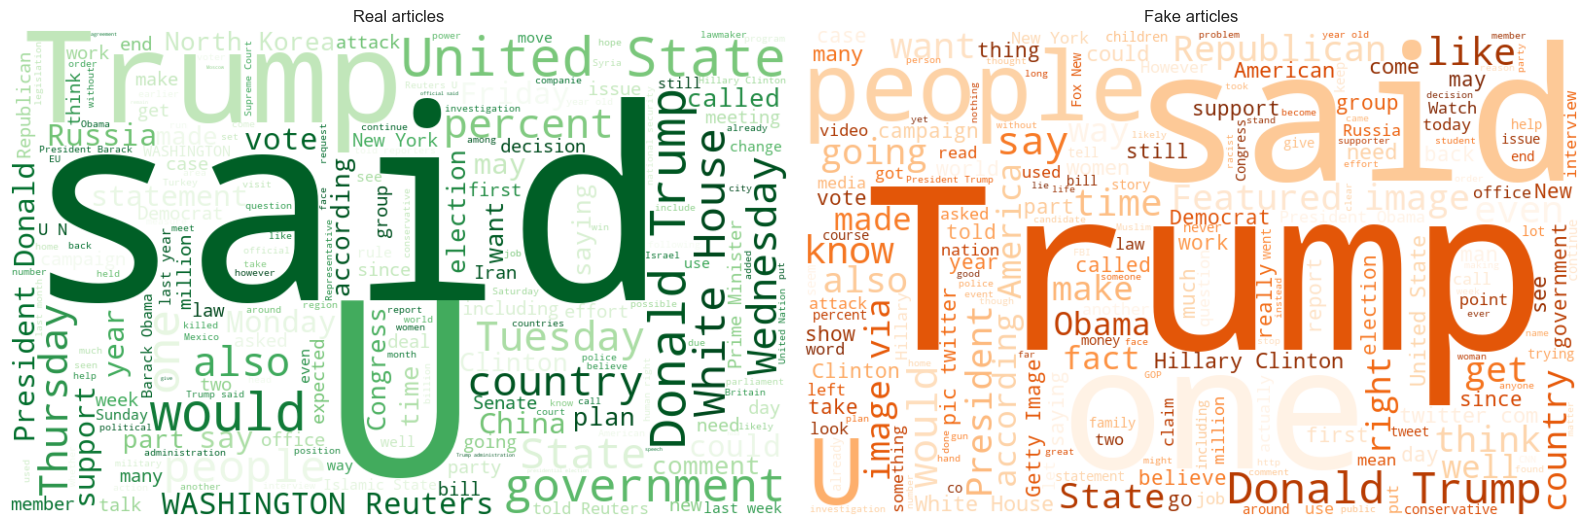

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

real_text = ' '.join(df[df['label'] == 1]['text'].astype(str).tolist())
fake_text = ' '.join(df[df['label'] == 0]['text'].astype(str).tolist())

wc_real = WordCloud(width=800, height=500, background_color='white', stopwords=STOPWORDS, colormap='Greens').generate(real_text)
wc_fake = WordCloud(width=800, height=500, background_color='white', stopwords=STOPWORDS, colormap='Oranges').generate(fake_text)

axes[0].imshow(wc_real, interpolation='bilinear')
axes[0].set_title('Real articles')
axes[0].axis('off')

axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].set_title('Fake articles')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../images/wordclouds.png', dpi=150)
plt.show()


## 9. Vocabulary Size (Unique Words per Class)

**Why we do this:** vocabulary richness (the number of distinct words used) can differ meaningfully between classes and affects how large the TF-IDF feature space will be .


In [ ]:
def unique_vocab_size(text_series):
    vocab = set()
    for text in text_series:
        tokens = word_tokenize(str(text).lower())
        vocab.update(t for t in tokens if t.isalpha())
    return len(vocab)

real_vocab = unique_vocab_size(df[df['label'] == 1]['text'])
fake_vocab = unique_vocab_size(df[df['label'] == 0]['text'])

print(f"Unique vocabulary — Real articles: {real_vocab:,}")
print(f"Unique vocabulary — Fake articles: {fake_vocab:,}")


Unique vocabulary — Real articles: 61,671
Unique vocabulary — Fake articles: 75,837


## 10. Summary of Findings


**Final dataset size and class balance:** 44,898 raw articles → 38,646 after removing 6,252 duplicate article bodies (14% of the raw data was duplicates — worth noting as a real, non-trivial cleaning step). Class balance: 54.8% real (21,191) vs. 45.2% fake (17,455) — mildly imbalanced, close enough that accuracy remains a reasonably trustworthy metric alongside F1.

**Does length meaningfully separate the classes?** Yes. Fake articles average 425 words vs. 385 for real — about 10% longer on average, with fake also showing higher variance (std 355 vs. 274). Not a huge gap, but real and consistent enough to be a genuine (if modest) signal, not noise.

**Top-word lists** — genuine signal or dataset artifact? Both, and the before/after comparison confirms it directly:

Before cleaning, real news top words include reuters (#3) and washington (#15) — the wire-service dateline artifact, exactly as predicted in the research report.
After Phase 6 cleaning, both tokens disappear entirely from the top-15 real-news list — direct evidence the dateline-removal step worked as intended, not just a theoretical fix.
What's left after cleaning looks like genuine signal: real news leans on republican, government, official, party; fake news leans on just, like, clinton, obama, right — more opinion-flavored and named-individual-heavy, consistent with the sensationalized-language pattern the literature review predicted.

Surprises in the least-frequent words: the tail is mostly rare proper nouns and foreign names (vinogradova, ghaani, borghesani) — expected noise. But a few entries look like genuine artifacts worth flagging: pjkyqx (looks like a garbled/scraped string, not a real word) and governmentsach (likely two words merged — probably "government" + "Sachs" glued together by a missing space during scraping). These didn't hurt model performance here since TF-IDF's min_df=5 filters them out automatically, but they're a sign the raw scrape has occasional concatenation errors — worth a stricter regex (e.g., filtering tokens with no vowels, or a minimum corpus-frequency threshold before EDA) if you wanted cleaner vocabulary statistics specifically.

One more finding not in the original four prompts but worth flagging: fake articles have a noticeably larger unique vocabulary than real articles (70,532 vs. 51,165 words) despite there being fewer fake articles overall — consistent with fake news being more topically scattered or informally written, while Reuters' real articles are more templated and repetitive in phrasing.



---
# Data Preprocessing


### Phase 2 — Text Preprocessing

In [ ]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
true_df = pd.read_csv('../datasets/True.csv')
fake_df = pd.read_csv('../datasets/Fake.csv')
true_df['label'] = 1
fake_df['label'] = 0
df = pd.concat([true_df, fake_df], axis=0, ignore_index=True)
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(df.shape)


(38646, 5)


## Remove Wire-Service Dateline Artifacts

Almost every real article in this dataset opens with a Reuters dateline pattern like `WASHINGTON (Reuters) -`, while fake articles essentially never have this exact structure. A model trained on the raw text can hit 95%+ accuracy simply by detecting this one pattern, without learning anything about what actually makes news fake. That's a dataset artifact, not a genuine signal, and it was called out explicitly as a risk in the research report and action plan. We strip it here, before lowercasing, because the pattern's capitalization is part of what makes it easy to detect and remove reliably with a regex.

**Theory:** a simple regex anchored to the start of the string matches `CITY (Reuters) -` or `CITY (Source) -` style prefixes and removes them, leaving the actual article content untouched.


In [ ]:
DATELINE_PATTERN = re.compile(r'^[A-Z][A-Za-z.,\s]*\((Reuters|AP|AFP)\)\s*-\s*')

def remove_dateline(text):
    return DATELINE_PATTERN.sub('', str(text))

# Quick check on a few real-article samples
for sample in df[df['label'] == 1]['text'].head(3):
    print(repr(sample[:80]), '->', repr(remove_dateline(sample)[:80]))
    print()


'WASHINGTON (Reuters) - U.S. President Donald Trump on Thursday will sign a direc' -> 'U.S. President Donald Trump on Thursday will sign a directive asking for a speed'

'WASHINGTON/CARACAS (Reuters) - Venezuelan President Nicolas Maduro said on Wedne' -> 'WASHINGTON/CARACAS (Reuters) - Venezuelan President Nicolas Maduro said on Wedne'

'MOSCOW (Reuters) - Russia’s Foreign Ministry declined on Tuesday to confirm or d' -> 'Russia’s Foreign Ministry declined on Tuesday to confirm or deny reported plans '



## Lowercasing

**Why:** without lowercasing, `"Reuters"`, `"reuters"`, and `"REUTERS"` would be treated as three different tokens by any downstream vectorizer, artificially inflating vocabulary size and splitting a word's signal across multiple features. Lowercasing is almost always the first normalization step in an NLP pipeline.

**Common mistake:** lowercasing *after* removing punctuation-sensitive things like URLs or acronyms you might want to detect — order matters less here, but it's worth doing early since almost every later step benefits from consistent casing.


In [ ]:
def to_lowercase(text):
    return str(text).lower()


##  Remove HTML Tags

**Why:** scraped news text sometimes retains stray HTML remnants (`&amp;`, `<br>`, leftover tags) from the original web page. These are not meaningful words and should be stripped before tokenization, or they'll show up as noise tokens like `br` or `amp` in the vocabulary.

**Theory:** a regex matching anything between angle brackets (`< ... >`) removes tags; HTML entities are unescaped separately using Python's built-in `html` module.


In [ ]:
import html as html_lib

HTML_TAG_PATTERN = re.compile(r'<.*?>')

def remove_html(text):
    text = html_lib.unescape(str(text))       # e.g. &amp; -> &
    text = HTML_TAG_PATTERN.sub(' ', text)    # e.g. <br> -> ' '
    return text


##  Remove URLs

**Why:** URLs are high-entropy strings that are essentially unique per document — they add vocabulary size without adding generalizable signal, and can leak source information (e.g. a domain name) in the same way the Reuters dateline does.

**Theory:** a regex matches `http://`, `https://`, and bare `www.` prefixed strings up to the next whitespace.


In [ ]:
URL_PATTERN = re.compile(r'(https?://\S+|www\.\S+)')

def remove_urls(text):
    return URL_PATTERN.sub(' ', str(text))


##  Remove Punctuation

**Why:** punctuation marks are not informative word-level features for a bag-of-words style model (TF-IDF or Word2Vec on whole words). Removing them prevents `"fake!"` and `"fake"` from being treated as different tokens.

**Common mistake:** removing punctuation *before* sentence tokenization elsewhere in your pipeline — sentence counts in the EDA notebook were computed on the raw text for exactly this reason. Here, since we're preparing tokens for modeling rather than counting sentences, removing punctuation is the right call.


In [ ]:
PUNCT_TABLE = str.maketrans('', '', string.punctuation)

def remove_punctuation(text):
    return str(text).translate(PUNCT_TABLE)


##  Remove Numbers

**Why:** standalone digits (dates, statistics, page numbers) rarely generalize as classification features — the same number appearing in one article is unlikely to appear in another, so it mostly adds sparse, low-value dimensions to the feature space. Some pipelines keep numbers if the task specifically depends on them (e.g. financial fraud detection); for general fake-news style classification, removing them is standard practice.

**Best practice:** if you later find a strong number-related signal in this dataset (e.g. specific years tied to a wave of fake articles), it's worth revisiting this decision — preprocessing choices should be checked against the EDA insights, not applied blindly.


In [ ]:
NUMBER_PATTERN = re.compile(r'\d+')

def remove_numbers(text):
    return NUMBER_PATTERN.sub(' ', str(text))


##  Remove Emojis

**Why:** the ISOT dataset is plain-text news articles, so emojis are rare, but this step is included for robustness and because it's part of the required pipeline for general-purpose news/social text. Emoji characters fall in specific Unicode ranges, which a regex can target directly.

**Expected output:** on this particular dataset, this step will typically change very little — that's expected, not a bug.


In [ ]:
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002700-\U000027BF"
    "\U0001F900-\U0001F9FF"
    "]+", flags=re.UNICODE)

def remove_emojis(text):
    return EMOJI_PATTERN.sub(' ', str(text))


##  Tokenization

**Why:** tokenization splits a continuous string of text into a list of individual word tokens. Every remaining step (stopword removal, lemmatization) operates on the token list, not on the raw string, so this is the pivot point of the pipeline.

**Theory:** `nltk.word_tokenize` uses the Punkt tokenizer, which handles contractions and punctuation edge cases more robustly than a naive `str.split()`.


In [ ]:
def tokenize(text):
    return word_tokenize(str(text))


##  Stopword Removal

**Why:** stopwords ("the", "is", "and", "a", etc.) are extremely frequent across almost every document regardless of class, so they contribute little discriminative signal while dominating raw frequency counts. Removing them lets both TF-IDF and Word2Vec focus their capacity on more meaningful vocabulary.

**Common mistake:** removing stopwords *before* tokenization — you need a token list to check each word against the stopword set, not a raw string.


In [ ]:
def remove_stopwords(tokens):
    return [t for t in tokens if t.lower() not in STOPWORDS]


##  Lemmatization

**Why:** lemmatization reduces inflected word forms to their dictionary base form ("running" -> "run", "better" -> "good" with the right POS tag, "articles" -> "article"), so that different grammatical forms of the same concept are treated as one feature instead of several. This directly shrinks vocabulary size and concentrates signal.

**Lemmatization vs. stemming:** stemming (e.g. Porter stemmer) chops word endings using crude rules and can produce non-words ("studies" -> "studi"); lemmatization uses a vocabulary and morphological analysis to return real words, which is more interpretable and generally preferred for this kind of project, at the cost of being somewhat slower.

**Note on POS tagging:** `WordNetLemmatizer` defaults to treating every word as a noun unless told otherwise. T he default noun-based lemmatization is a reasonable trade-off between accuracy and pipeline complexity; a more advanced version could POS-tag each token first and pass the correct tag in.


In [ ]:
def lemmatize(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]


##  Full Pipeline

Now we combine every step above, in order, into one function, and apply it to the whole dataset. The function returns a cleaned string (tokens rejoined with spaces) rather than a list, since that's the input format `TfidfVectorizer`; the token list version is kept as well for Word2Vec, which trains directly on lists of tokens.

**Expected output:** a new `clean_text` column (string, for TF-IDF) and a `tokens` column (list of strings, for Word2Vec). 


In [ ]:
def clean_text_pipeline(text):
    text = remove_dateline(text)
    text = to_lowercase(text)
    text = remove_html(text)
    text = remove_urls(text)
    text = remove_punctuation(text)
    text = remove_numbers(text)
    text = remove_emojis(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize(tokens)
    return tokens

df['tokens'] = df['text'].apply(clean_text_pipeline)
df['clean_text'] = df['tokens'].apply(lambda toks: ' '.join(toks))

df[['text', 'clean_text']].head()


,text,clean_text
0,"Here s the fake black guy, Shaun King weighing...",fake black guy shaun king weighing awesome ber...
1,While Trump s Secretary of State was visiting ...,trump secretary state visiting un base border ...
2,Join Patrick every week here at 21WIRE.TV for ...,join patrick every week wiretv news view analy...
3,The size of Donald Trump s hands seems to be a...,size donald trump hand seems issue even socall...
4,WASHINGTON (Reuters) - U.S. President Donald T...,u president donald trump thursday sign directi...


In [ ]:
# Save the cleaned dataset so Phases 7-8 don't need to re-run this pipeline from scratch
df.to_csv('../dataset/cleaned_news.csv', index=False)
print(f"Saved cleaned_news.csv with {len(df)} rows")


Saved cleaned_news.csv with 38646 rows


## Summary

- Removed dataset-specific leakage (wire-service datelines) before any generic cleaning, so the model can't shortcut on source formatting
- Applied the standard normalization chain: lowercase -> HTML -> URLs -> punctuation -> numbers -> emojis
- Tokenized, removed stopwords, and lemmatized to reduce vocabulary to meaningful base forms
- Saved the result to `dataset/cleaned_news.csv`, with both a `clean_text` string column (for TF-IDF) and a `tokens` list column (for Word2Vec)

 

---
# Feature Engineering


### Phase 3 — TF-IDF Feature Engineering

## Theory

TF-IDF scores each word in each document by combining two ideas:

- **Term Frequency (TF)** — how often a word appears in a specific document. A word appearing often in *this* article is likely relevant to what the article is about.
- **Inverse Document Frequency (IDF)** — how rare the word is across the *whole corpus*. Words that appear in almost every document (even after stopword removal) carry little discriminative value and get down-weighted; words that appear in only a handful of documents get up-weighted.

**Formula:**

```
TF-IDF(t, d, D) = TF(t, d) × log( N / (1 + DF(t)) )
```

where `t` is a term, `d` is a document, `D` is the full corpus, `N` is the total number of documents, and `DF(t)` is the number of documents containing term `t`. The `+1` in the denominator prevents division by zero for terms that (in theory) appear in every document.

**Advantages:**
- Fast to compute, even on tens of thousands of documents
- Produces an interpretable, sparse feature space — each dimension is literally one vocabulary word
- Performs very well as input to linear models (SVM) and probabilistic models (Naive Bayes) on text classification tasks
- No training required beyond counting — unlike Word2Vec, there's no iterative learning process

**Limitations:**
- Treats every word as independent — "president" and "leader" get unrelated feature dimensions even though they're semantically close
- Feature space size grows with vocabulary size, which can become large (tens of thousands of columns) without a `max_features` cap


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv('../dataset/cleaned_news.csv')
df['clean_text'] = df['clean_text'].fillna('')
print(df.shape)
df[['clean_text', 'label']].head()


(38646, 7)


,clean_text,label
0,fake black guy shaun king weighing awesome ber...,0
1,trump secretary state visiting un base border ...,0
2,join patrick every week wiretv news view analy...,0
3,size donald trump hand seems issue even socall...,0
4,u president donald trump thursday sign directi...,1


## Worked Mini-Example

Before running TF-IDF on the full ~40k-article corpus, it helps to see it work on three tiny documents where you can check the output by hand. This confirms the vectorizer behaves as expected before trusting it on the full dataset.


In [ ]:
demo_docs = [
    "the president said the economy is strong",
    "the president denied the fake claim",
    "scientists discover new evidence in study",
]
demo_vectorizer = TfidfVectorizer()
demo_matrix = demo_vectorizer.fit_transform(demo_docs)

demo_df = pd.DataFrame(demo_matrix.toarray(), columns=demo_vectorizer.get_feature_names_out())
demo_df


,claim,denied,discover,economy,evidence,fake,in,is,new,president,said,scientists,strong,study,the
0,0.000000,0.000000,0.000000,0.380914,0.000000,0.000000,0.000000,0.380914,0.000000,0.289695,0.380914,0.000000,0.380914,0.000000,0.579391
1,0.411973,0.411973,0.000000,0.000000,0.000000,0.411973,0.000000,0.000000,0.000000,0.313316,0.000000,0.000000,0.000000,0.000000,0.626632
2,0.000000,0.000000,0.408248,0.000000,0.408248,0.000000,0.408248,0.000000,0.408248,0.000000,0.000000,0.408248,0.000000,0.408248,0.000000


**How to read this:** notice that `"the"` and `"president"`, which appear in two of the three documents, get lower TF-IDF weight than words like `"economy"` or `"study"` that appear in only one document — exactly the down-weighting-of-common-terms behavior the IDF component is designed to produce.


## Fitting TF-IDF on the Full Corpus

**Important — avoiding data leakage:** in a real train/test workflow, the vectorizer must be `fit` only on the training split (Phase 9), then used to `transform` the test split, so that IDF statistics never "see" test documents. The fit shown here, on the *entire* cleaned corpus, is for exploratory purposes only — inspecting vocabulary size, sparsity, and top terms per class. The actual vectorizer used for model training in Phase 10 will be re-fit on the training split alone, inside that notebook.

**Parameters explained:**
- `max_features=5000` caps the vocabulary to the 5,000 highest-scoring terms overall, keeping the feature matrix a manageable size and reducing overfitting risk from very rare words
- `ngram_range=(1, 2)` includes both single words (unigrams) and two-word phrases (bigrams), letting the model pick up short phrases like "breaking news" that a single word wouldn't capture
- `min_df=5` ignores terms that appear in fewer than 5 documents — usually typos or very rare proper nouns


In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
tfidf_matrix = tfidf.fit_transform(df['clean_text'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))
print("Matrix sparsity: {:.2%} non-zero".format(tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])))


TF-IDF matrix shape: (38646, 5000)
Vocabulary size: 5000
Matrix sparsity: 2.72% non-zero


**Expected output:** a matrix with one row per article and up to 5,000 columns (fewer if the corpus doesn't have that many qualifying terms), with sparsity typically well under 1% — most words in the vocabulary don't appear in most documents, which is exactly why TF-IDF matrices are stored in sparse format rather than as dense arrays.


## Top TF-IDF Terms by Class

**Why we do this:** averaging the TF-IDF score of each term across all real articles vs. all fake articles surfaces which terms most distinguish the two classes — a numeric, weighted version of the word-frequency bar charts from the EDA notebook, but now reflecting rarity as well as frequency.


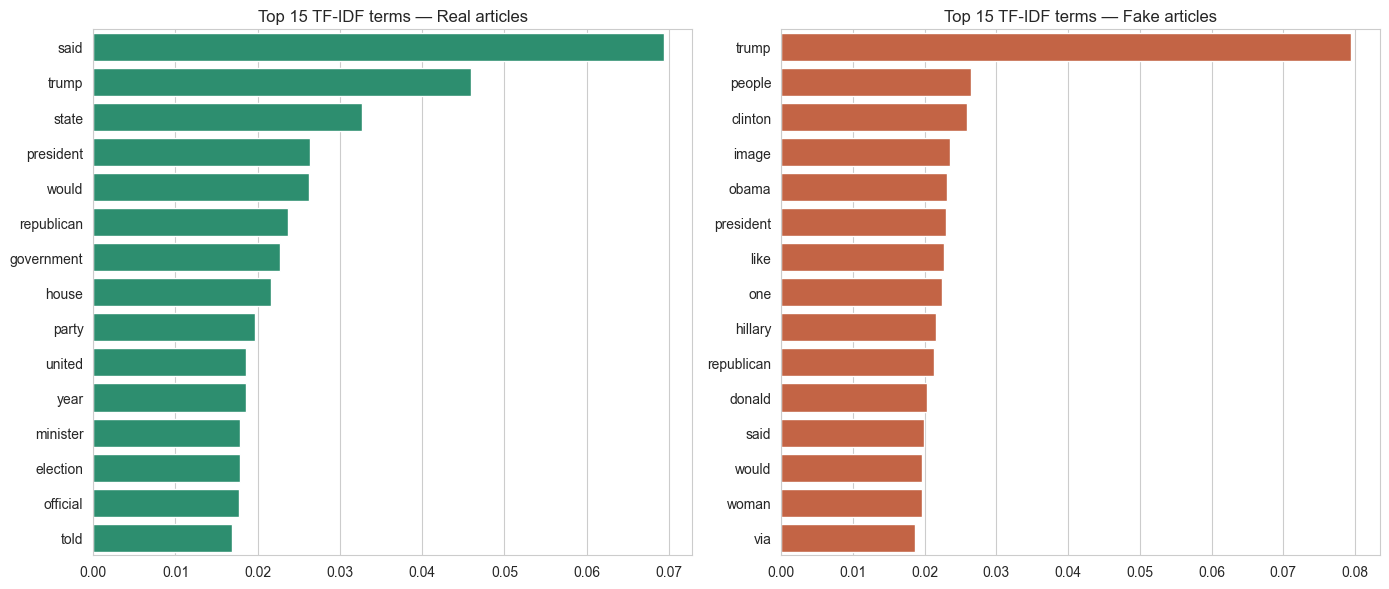

In [ ]:
feature_names = np.array(tfidf.get_feature_names_out())

real_mean_tfidf = np.asarray(tfidf_matrix[df['label'].values == 1].mean(axis=0)).ravel()
fake_mean_tfidf = np.asarray(tfidf_matrix[df['label'].values == 0].mean(axis=0)).ravel()

top_real_idx = real_mean_tfidf.argsort()[::-1][:15]
top_fake_idx = fake_mean_tfidf.argsort()[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=real_mean_tfidf[top_real_idx], y=feature_names[top_real_idx], ax=axes[0], color='#1D9E75')
axes[0].set_title('Top 15 TF-IDF terms — Real articles')
sns.barplot(x=fake_mean_tfidf[top_fake_idx], y=feature_names[top_fake_idx], ax=axes[1], color='#D85A30')
axes[1].set_title('Top 15 TF-IDF terms — Fake articles')
plt.tight_layout()
plt.savefig('../images/top_tfidf_terms.png', dpi=150)
plt.show()




- **Common mistake:** fitting `TfidfVectorizer` on the entire dataset (including test data) before splitting — this leaks test-set vocabulary statistics into training and inflates reported performance. Always fit on train only.
- **Common mistake:** forgetting to cap `max_features` on a large corpus, leading to a huge, slow, mostly-empty feature matrix.
- **Best practice:** save the fitted vectorizer (via `pickle`) alongside the trained model, since the exact same vocabulary and IDF weights are required to transform any new text at prediction time — a vectorizer refit on different data will not produce compatible feature vectors.
- **Best practice:** try both `ngram_range=(1,1)` and `(1,2)` when tuning  and compare — bigrams help on some datasets and add noise on others.

## Summary

- TF-IDF converts cleaned article text into a sparse, weighted bag-of-words matrix
- A 5,000-term vocabulary with unigrams and bigrams keeps the feature space manageable
- Top terms per class previewed the kind of signal SVM and Naive Bayes will exploit 
- The full-corpus fit shown here is exploratory only; the modeling notebook will re-fit TF-IDF on the training split alone to avoid leakage


---
### Phase 4 — Word2Vec Feature Engineering

### Theory and Architecture

Word2Vec (Mikolov et al., 2013) is a shallow neural network trained on a simple self-supervised task: predict words from their context, or context from a word. No manual labels are needed — the "labels" come from word co-occurrence in the corpus itself. There are two architectures:

- **CBOW (Continuous Bag of Words):** predicts a target word from the average of its surrounding context words. Faster to train, tends to work well on frequent words.
- **Skip-gram:** predicts the surrounding context words from a single target word. Slower to train, but tends to represent rare words better, since each occurrence of a rare word generates multiple training pairs (one per context word).

During training, each word is assigned a dense vector (typically 100–300 dimensions). The network's hidden-layer weights, after training, *are* the word vectors — the network itself is discarded once training finishes; only the learned vectors are kept.

**Advantages over TF-IDF:**
- Captures semantic similarity — similar words get similar vectors, which TF-IDF's independent-dimension assumption cannot represent
- Dense, low-dimensional representation (e.g. 100 dimensions vs. thousands of sparse TF-IDF columns)
- Vectors trained on this project's own corpus reflect news-specific word usage, rather than generic web text

**Trade-offs:**
- Needs a reasonably large corpus to learn good vectors — rare words with few occurrences get poor representations
- Less interpretable than TF-IDF — individual dimensions don't correspond to specific words or concepts
- To get one vector per *document* (not per word) for classical ML models, per-word vectors must be aggregated, typically by averaging, which loses word order and can dilute signal from a few important words among many neutral ones


In [ ]:
import pandas as pd
import numpy as np
import ast
from gensim.models import Word2Vec

df = pd.read_csv('../dataset/cleaned_news.csv')

# tokens were saved as a stringified list in the CSV; convert back to an actual Python list
df['tokens'] = df['tokens'].apply(ast.literal_eval)
print(df.shape)
df['tokens'].head()


(38646, 7)


0    [fake, black, guy, shaun, king, weighing, awes...
1    [trump, secretary, state, visiting, un, base, ...
2    [join, patrick, every, week, wiretv, news, vie...
3    [size, donald, trump, hand, seems, issue, even...
4    [u, president, donald, trump, thursday, sign, ...
Name: tokens, dtype: object

### Training the Word2Vec Model

**Parameters explained:**
- `vector_size=100` — the dimensionality of each word vector; 100–300 is typical for a corpus this size
- `window=5` — how many words on each side count as "context" for a given target word
- `min_count=5` — ignore words appearing fewer than 5 times in the whole corpus, since Word2Vec can't learn a reliable vector from a handful of occurrences
- `sg=1` — use Skip-gram (set to `0` for CBOW); Skip-gram is chosen here because news vocabulary includes many moderately rare proper nouns and topical terms, and Skip-gram tends to represent those better
- `workers=4` — number of CPU threads for parallel training

**Expected output:** training on ~40k articles typically completes in well under a minute on a laptop CPU — Word2Vec at this scale is lightweight compared to a deep learning model.


In [ ]:
w2v_model = Word2Vec(
    sentences=df['tokens'].tolist(),
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    workers=4,
    seed=42,
)

print("Vocabulary size:", len(w2v_model.wv))


Vocabulary size: 40727


### Sanity-Checking the Embeddings

**Why we do this:** before trusting the vectors for modeling, check that they've actually learned something sensible — words that are genuinely related in meaning should show up as each other's nearest neighbors. This is the fastest way to catch a training misconfiguration (e.g. `min_count` too high, corpus too small) before it silently hurts downstream model accuracy.


In [ ]:
# Try a couple of words that should have intuitive neighbors in a news corpus
for probe_word in ['president', 'government', 'fake']:
    if probe_word in w2v_model.wv:
        print(f"Most similar to '{probe_word}':")
        for word, score in w2v_model.wv.most_similar(probe_word, topn=5):
            print(f"   {word}: {score:.3f}")
        print()
    else:
        print(f"'{probe_word}' not in vocabulary (below min_count threshold)")


Most similar to 'president':
   presidency: 0.695
   presidentwhen: 0.670
   renomination: 0.665
   presidentelect: 0.655
   obamaon: 0.654

Most similar to 'government':
   authority: 0.655
   haririled: 0.643
   relinquish: 0.640
   montoro: 0.635
   conditional: 0.633

Most similar to 'fake':
   purveyor: 0.770
   drudge: 0.770
   washpost: 0.747
   disingenuously: 0.742
   posttruth: 0.739



## Aggregating Word Vectors into Document Vectors

**Why we do this:** Random Forest, SVM, and Naive Bayes all expect one fixed-length feature vector per document, not a variable-length sequence of per-word vectors. Averaging every in-vocabulary word's vector for a document is the standard, simplest aggregation — it produces a single 100-dimensional vector per article that captures the article's overall semantic "center of mass."




In [ ]:
def document_vector(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

doc_vectors = np.vstack(df['tokens'].apply(lambda toks: document_vector(toks, w2v_model)))
print("Document-vector matrix shape:", doc_vectors.shape)


Document-vector matrix shape: (38646, 100)


## Comparing TF-IDF and Word2Vec Representations

| | TF-IDF | Word2Vec (averaged) |
|---|---|---|
| Dimensionality | Thousands (sparse) | ~100–300 (dense) |
| Captures semantic similarity | No | Yes |
| Interpretability | High — each dimension is a word | Low — dimensions are latent |
| Training required | No (just counting) | Yes (shallow neural network) |
| Sensitive to corpus size | Less | More — needs enough occurrences per word |




In [ ]:
# Save the trained Word2Vec model and the aggregated document vectors for use in Phase 10
w2v_model.save('../models/word2vec.model')
np.save('../dataset/w2v_document_vectors.npy', doc_vectors)
print("Saved word2vec.model and w2v_document_vectors.npy")


Saved word2vec.model and w2v_document_vectors.npy




- **Common mistake:** training Word2Vec on the full dataset including what will become the test split, then using the resulting vectors for both train and test — this is a milder form of leakage than TF-IDF's, since Word2Vec learns general language statistics rather than per-document labels, but for a fully rigorous pipeline the model should still be trained on the training split only.
- **Common mistake:** using a `min_count` that's too low, which fills the vocabulary with poorly-learned vectors for words seen only once or twice.
- **Best practice:** always run the nearest-neighbor sanity check above before moving on — nonsensical neighbors are a fast, cheap way to catch a broken training run.
- **Best practice:** if the averaged-vector approach underperforms TF-IDF, consider trying TF-IDF-weighted averaging (weighting each word's vector by its TF-IDF score before averaging) as a documented stretch improvement, rather than abandoning Word2Vec outright.

## Summary

- Trained a Skip-gram Word2Vec model directly on this project's cleaned news corpus
- Verified the embeddings with a nearest-neighbor sanity check
- Aggregated per-word vectors into one 100-dimensional vector per article via averaging
- Saved both the Word2Vec model and the resulting document-vector matrix for use alongside the TF-IDF matrix.


---
## Phase 5 — Train/Test Split

#### Why a Train/Test Split?

If a model is evaluated on the same data it was trained on, it can score very well simply by memorizing that data, without having learned anything that generalizes to new, unseen articles — a failure mode called overfitting. Holding out a test set the model never sees during training gives an honest estimate of how it would perform on genuinely new articles after deployment. This is the single most important safeguard against reporting misleadingly optimistic results.

## Why `random_state`?

`train_test_split` shuffles the data before splitting. Without fixing `random_state` to a specific integer, every run of the notebook would produce a *different* random split, meaning results would not be reproducible from one run to the next — an issue both for debugging ("why did my number change?") and for anyone trying to verify your reported results later. Fixing `random_state=42` (any consistent integer works; 42 is a common convention) guarantees the exact same split every time the notebook is re-run.

## Why `stratify`?

Passing `stratify=y` tells `train_test_split` to preserve the original class proportions in both the train and test sets. Without it, a random split could by chance produce a test set with a noticeably different real/fake ratio than the full dataset, which would make metrics like accuracy harder to compare across runs and, in the worst case, could leave one class underrepresented enough to make evaluation unreliable. Since EDA showed only a mild class imbalance in this dataset, stratification is cheap insurance rather than a fix for a severe problem — but it's standard practice regardless of how balanced the classes look.

## Why an 80/20 Split?

An 80/20 (or similar 75/25, 70/30) split balances two competing needs: the training set needs to be large enough for the model to learn robust patterns, while the test set needs to be large enough for the evaluation metrics themselves to be statistically reliable rather than noisy. On a dataset of this size (tens of thousands of articles), an 80/20 split leaves both a large training set and a test set of several thousand articles — comfortably enough for stable precision/recall/F1 estimates. Smaller datasets sometimes use a 70/30 split to guarantee a large enough test set; very large datasets can push training to 90% or more since even 10% is still plenty of test data.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse

df = pd.read_csv('../dataset/cleaned_news.csv')
df['clean_text'] = df['clean_text'].fillna('')
w2v_doc_vectors = np.load('../dataset/w2v_document_vectors.npy')

y = df['label'].values
print("Dataset size:", len(df))
print("Class balance:", np.bincount(y) / len(y))


Dataset size: 38646
Class balance: [0.45163794 0.54836206]


## Splitting the Row Indices

**Design choice:** rather than splitting the TF-IDF matrix and the Word2Vec matrix independently (which could put different articles in each model's "test set"), we split the row *indices* once and apply that same split to both feature matrices and the label array. This guarantees that when comparing TF-IDF-based models against Word2Vec-based models, every model was tested on the exact same held-out articles — a fair, apples-to-apples comparison.


In [ ]:
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Train size: {len(train_idx)} ({len(train_idx)/len(df):.1%})")
print(f"Test size:  {len(test_idx)} ({len(test_idx)/len(df):.1%})")
print()
print("Train class balance:", np.bincount(y[train_idx]) / len(train_idx))
print("Test class balance: ", np.bincount(y[test_idx]) / len(test_idx))


Train size: 30916 (80.0%)
Test size:  7730 (20.0%)

Train class balance: [0.45164316 0.54835684]
Test class balance:  [0.45161708 0.54838292]


## Fitting TF-IDF on the Training Split Only

**This is the leakage fix :** the vectorizer is fit only on `clean_text.iloc[train_idx]`, so its vocabulary and IDF weights are learned exclusively from training articles. The test split is then only ever `.transform()`-ed, never `.fit()`-ed — it uses the vocabulary already learned from training, exactly mimicking how the model would encounter genuinely new text after deployment.


In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X_train_tfidf = tfidf.fit_transform(df['clean_text'].iloc[train_idx])
X_test_tfidf = tfidf.transform(df['clean_text'].iloc[test_idx])

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape: ", X_test_tfidf.shape)


TF-IDF train shape: (30916, 5000)
TF-IDF test shape:  (7730, 5000)


In [ ]:
X_train_w2v = w2v_doc_vectors[train_idx]
X_test_w2v = w2v_doc_vectors[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print("Word2Vec train shape:", X_train_w2v.shape)
print("Word2Vec test shape: ", X_test_w2v.shape)


Word2Vec train shape: (30916, 100)
Word2Vec test shape:  (7730, 100)


## Saving the Split

Both feature representations, split into train/test, plus the label arrays and the fitted TF-IDF vectorizer (which will also be needed again to transform new text at prediction time).


In [ ]:
import pickle

sparse.save_npz('../dataset/X_train_tfidf.npz', X_train_tfidf)
sparse.save_npz('../dataset/X_test_tfidf.npz', X_test_tfidf)
np.save('../dataset/X_train_w2v.npy', X_train_w2v)
np.save('../dataset/X_test_w2v.npy', X_test_w2v)
np.save('../dataset/y_train.npy', y_train)
np.save('../dataset/y_test.npy', y_test)

with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Saved train/test splits for both feature sets, and the fitted TF-IDF vectorizer.")


Saved train/test splits for both feature sets, and the fitted TF-IDF vectorizer.




- **Common mistake:** fitting TF-IDF (or any preprocessing step with learned statistics) on the full dataset before splitting — this is data leakage and inflates reported performance.
- **Common mistake:** splitting TF-IDF and Word2Vec data independently with different random seeds, making later model comparisons invalid because each representation was tested on a different set of articles.
- **Best practice:** always print and eyeball the class balance of both splits after calling `train_test_split`, even when `stratify` is used — it takes one line and catches accidental mistakes immediately.
- **Best practice:** save the fitted vectorizer, not just the transformed matrices — you'll need it again for any new, unseen text at prediction time in the Streamlit app (Phase 13).

## Summary

- Split row indices once (80/20, stratified, `random_state=42`) and applied consistently across both feature representations
- Fit TF-IDF on the training split only, transformed the test split, avoiding leakage
- Saved train/test arrays for TF-IDF and Word2Vec, plus the fitted vectorizer, ready for Phase 10 model training


---
## Phase 6 — Model Training

In [ ]:
import numpy as np
import pickle
import time
from scipy import sparse
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

X_train_tfidf = sparse.load_npz('../dataset/X_train_tfidf.npz')
X_test_tfidf = sparse.load_npz('../dataset/X_test_tfidf.npz')
X_train_w2v = np.load('../dataset/X_train_w2v.npy')
X_test_w2v = np.load('../dataset/X_test_w2v.npy')
y_train = np.load('../dataset/y_train.npy')
y_test = np.load('../dataset/y_test.npy')

trained_models = {}  # populated as we go; used by Phase 11


### A Note on Word2Vec and Naive Bayes

`MultinomialNB`, the standard Naive Bayes variant for text, assumes every feature is a non-negative count or frequency — which fits TF-IDF scores perfectly, since they're always ≥ 0. Word2Vec vectors, however, are dense and can contain negative values (they're coordinates in a learned semantic space, not counts). For that reason, this notebook uses `MultinomialNB` for the TF-IDF representation and `GaussianNB`, which models each feature as normally distributed and accepts negative values, for the Word2Vec representation. This is a deliberate, documented choice — not an inconsistency — and it's exactly the kind of detail worth calling out explicitly in a report.

## Model 1: Naive Bayes

 Naive Bayes applies Bayes' theorem to compute the probability of each class given the observed features, under the simplifying ("naive") assumption that all features are conditionally independent given the class. Despite that assumption rarely holding for natural language, where word choices are highly correlated, Naive Bayes remains a strong, fast baseline for text classification.

**Advantages:**
- Extremely fast to train, even on a 5,000-dimension TF-IDF matrix
- Performs well with relatively little data
- Naturally probabilistic — outputs a class probability, useful for the confidence score in the Streamlit app

**Disadvantages:**
- The independence assumption is unrealistic for language, which can cap accuracy relative to models that can exploit feature interactions
- `GaussianNB` in particular can underperform on dense embeddings where features aren't well described by a single Gaussian per class


In [ ]:
start = time.time()
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
print(f"Naive Bayes (TF-IDF) trained in {time.time() - start:.2f}s")

start = time.time()
nb_w2v = GaussianNB()
nb_w2v.fit(X_train_w2v, y_train)
print(f"Naive Bayes (Word2Vec) trained in {time.time() - start:.2f}s")

trained_models['NaiveBayes_TFIDF'] = nb_tfidf
trained_models['NaiveBayes_Word2Vec'] = nb_w2v


Naive Bayes (TF-IDF) trained in 0.08s
Naive Bayes (Word2Vec) trained in 0.11s


In [ ]:
# Prediction — same pattern for every model: .predict() for labels, .predict_proba() for confidence
pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
pred_nb_w2v = nb_w2v.predict(X_test_w2v)

print("Naive Bayes (TF-IDF) sample predictions:   ", pred_nb_tfidf[:10])
print("Naive Bayes (Word2Vec) sample predictions: ", pred_nb_w2v[:10])
print("Actual labels:                             ", y_test[:10])


Naive Bayes (TF-IDF) sample predictions:    [0 0 0 0 1 1 0 1 0 0]
Naive Bayes (Word2Vec) sample predictions:  [1 0 0 0 1 1 0 0 0 0]
Actual labels:                              [0 0 0 0 1 1 0 0 0 1]


## Model 2: Support Vector Machine (SVM)

**Theory:** SVM finds the hyperplane that separates the two classes with the maximum possible margin — the widest possible "buffer zone" between the closest points of each class. For text classification, a linear kernel is almost always used, since high-dimensional sparse text features (thousands of TF-IDF dimensions) tend to already be close to linearly separable, and a linear kernel is far cheaper to train than a non-linear one at this scale. `LinearSVC` is used here rather than `SVC(kernel='linear')` because it's specifically optimized for the linear case and scales much better to tens of thousands of rows.

**Advantages:**
- One of the strongest classical baselines for high-dimensional sparse text data
- Regularization (the `C` parameter) gives direct control over the overfitting/margin-width trade-off
- Works well on both TF-IDF and dense Word2Vec features

**Disadvantages:**
- `LinearSVC` doesn't output probabilities directly (it's a margin-based decision, not inherently probabilistic) — `CalibratedClassifierCV` or `SVC(probability=True)` is needed if a genuine confidence score is required, at extra computational cost
- Sensitive to the choice of `C`; under-regularized SVMs can overfit high-dimensional TF-IDF data


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

start = time.time()
svm_tfidf_base = LinearSVC(C=1.0, random_state=42, max_iter=5000)
svm_tfidf = CalibratedClassifierCV(svm_tfidf_base, cv=3)  # wraps LinearSVC to add predict_proba
svm_tfidf.fit(X_train_tfidf, y_train)
print(f"SVM (TF-IDF) trained in {time.time() - start:.2f}s")

start = time.time()
svm_w2v_base = LinearSVC(C=1.0, random_state=42, max_iter=5000)
svm_w2v = CalibratedClassifierCV(svm_w2v_base, cv=3)
svm_w2v.fit(X_train_w2v, y_train)
print(f"SVM (Word2Vec) trained in {time.time() - start:.2f}s")

trained_models['SVM_TFIDF'] = svm_tfidf
trained_models['SVM_Word2Vec'] = svm_w2v


SVM (TF-IDF) trained in 2.25s
SVM (Word2Vec) trained in 1.01s


In [ ]:
pred_svm_tfidf = svm_tfidf.predict(X_test_tfidf)
pred_svm_w2v = svm_w2v.predict(X_test_w2v)

print("SVM (TF-IDF) sample predictions:   ", pred_svm_tfidf[:10])
print("SVM (Word2Vec) sample predictions: ", pred_svm_w2v[:10])


SVM (TF-IDF) sample predictions:    [0 0 1 0 1 1 0 0 0 1]
SVM (Word2Vec) sample predictions:  [0 0 0 0 1 1 0 0 0 1]


## Model 3: Random Forest

Random Forest builds many decision trees, each trained on a bootstrap-sampled subset of the training data and, at each split, restricted to a random subset of features. The final prediction is the majority vote across all trees. This double randomization decorrelates the individual trees, reducing the overfitting that a single deep decision tree is prone to.

**Advantages:**
- Robust to irrelevant or noisy features, which a large TF-IDF vocabulary tends to contain plenty of
- Captures non-linear feature interactions that linear models (Naive Bayes, linear SVM) cannot
- `n_estimators` and `max_depth` give direct, intuitive control over the bias/variance trade-off

**Disadvantages:**
- Slower to train than Naive Bayes, particularly with many trees on a high-dimensional sparse matrix
- Less interpretable than a single decision tree — explaining *why* the forest predicted "fake" requires aggregate feature-importance analysis rather than reading one tree


In [ ]:
start = time.time()
rf_tfidf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf_tfidf.fit(X_train_tfidf, y_train)
print(f"Random Forest (TF-IDF) trained in {time.time() - start:.2f}s")

start = time.time()
rf_w2v = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf_w2v.fit(X_train_w2v, y_train)
print(f"Random Forest (Word2Vec) trained in {time.time() - start:.2f}s")

trained_models['RandomForest_TFIDF'] = rf_tfidf
trained_models['RandomForest_Word2Vec'] = rf_w2v


Random Forest (TF-IDF) trained in 64.13s
Random Forest (Word2Vec) trained in 26.76s


In [ ]:
pred_rf_tfidf = rf_tfidf.predict(X_test_tfidf)
pred_rf_w2v = rf_w2v.predict(X_test_w2v)

print("Random Forest (TF-IDF) sample predictions:   ", pred_rf_tfidf[:10])
print("Random Forest (Word2Vec) sample predictions: ", pred_rf_w2v[:10])


Random Forest (TF-IDF) sample predictions:    [0 0 0 0 1 1 0 0 0 0]
Random Forest (Word2Vec) sample predictions:  [0 0 0 0 1 1 0 1 0 0]


#### Saving All Trained Models

Every trained model is saved so Evaluation and Best Model Selection can load them without retraining.


In [ ]:
with open('../models/all_trained_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)

print("Saved", len(trained_models), "trained models:")
for name in trained_models:
    print(" -", name)


Saved 6 trained models:
 - NaiveBayes_TFIDF
 - NaiveBayes_Word2Vec
 - SVM_TFIDF
 - SVM_Word2Vec
 - RandomForest_TFIDF
 - RandomForest_Word2Vec



- **Common mistake:** using `MultinomialNB` on Word2Vec features — it will error or silently misbehave on negative values; use `GaussianNB` for dense embeddings instead.
- **Common mistake:** calling `.predict_proba()` directly on a bare `LinearSVC` — it doesn't implement that method; wrap it in `CalibratedClassifierCV` first if probabilities are needed.
- **Common mistake:** timing model training without a fixed `random_state` and then comparing runs — Random Forest and the calibration step in SVM both have stochastic elements, so seed everything for reproducible comparisons.
- **Best practice:** capture training time for each model (as done above) — it's a practical factor in model selection alongside raw accuracy, particularly if the final choice needs to run inside a responsive Streamlit app.

## Summary

- Trained six models total: {Naive Bayes, SVM, Random Forest} × {TF-IDF, Word2Vec}
- Used `MultinomialNB` for TF-IDF and `GaussianNB` for Word2Vec, and `CalibratedClassifierCV` around `LinearSVC` to get probability estimates for the Streamlit confidence score
- Saved all six trained models to `models/all_trained_models.pkl` for evaluation.

# Model Evaluation and Comparison
### Fake News Detection Using Advanced NLP

This notebook evaluates all six trained models (Naive Bayes, SVM, Random Forest × TF-IDF, Word2Vec) on the held-out test set from Phase 9, using accuracy, precision, recall, F1-score, confusion matrices, and ROC curves, then recommends a best model based on the actual numbers.




In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

X_test_tfidf = sparse.load_npz('../dataset/X_test_tfidf.npz')
X_test_w2v = np.load('../dataset/X_test_w2v.npy')
y_test = np.load('../dataset/y_test.npy')

with open('../models/all_trained_models.pkl', 'rb') as f:
    models = pickle.load(f)

# Map each model name to the correct test feature matrix
feature_for_model = {
    'NaiveBayes_TFIDF': X_test_tfidf, 'NaiveBayes_Word2Vec': X_test_w2v,
    'SVM_TFIDF': X_test_tfidf, 'SVM_Word2Vec': X_test_w2v,
    'RandomForest_TFIDF': X_test_tfidf, 'RandomForest_Word2Vec': X_test_w2v,
}
print("Loaded", len(models), "trained models")


Loaded 6 trained models


## Computing Metrics for Every Model

**Why each metric matters here specifically:**
- **Accuracy** — overall correctness; easy to read but can hide an imbalance between error types
- **Precision** (for the "fake" class) — of everything flagged as fake, how much genuinely was; low precision means real news gets wrongly censored
- **Recall** (for the "fake" class) — of everything genuinely fake, how much was caught; low recall means fake news slips through
- **F1-score** — the harmonic mean of precision and recall, used here as the primary single-number comparison metric since this project has no stated reason to weight false positives or false negatives more heavily than the other

In [ ]:
results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    X_test = feature_for_model[name]
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 ("real")

    predictions[name] = y_pred
    probabilities[name] = y_proba

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df.to_csv('../reports/model_comparison_results.csv', index=False)
results_df.round(4)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,SVM_TFIDF,0.9859,0.9857,0.9887,0.9872,0.9981
1,SVM_Word2Vec,0.9831,0.9828,0.9863,0.9846,0.9981
2,RandomForest_TFIDF,0.9777,0.9684,0.9917,0.9800,0.9983
3,RandomForest_Word2Vec,0.9699,0.9619,0.9840,0.9728,0.9951
4,NaiveBayes_TFIDF,0.9374,0.9429,0.9429,0.9429,0.9822
5,NaiveBayes_Word2Vec,0.9069,0.9157,0.9144,0.9150,0.9634


### Comparison Bar Chart

**How to read this graph:** each group of bars is one model; each color is one metric. This makes it easy to spot whether a model is uniformly strong across all metrics or has a lopsided precision/recall trade-off worth discussing in the write-up.

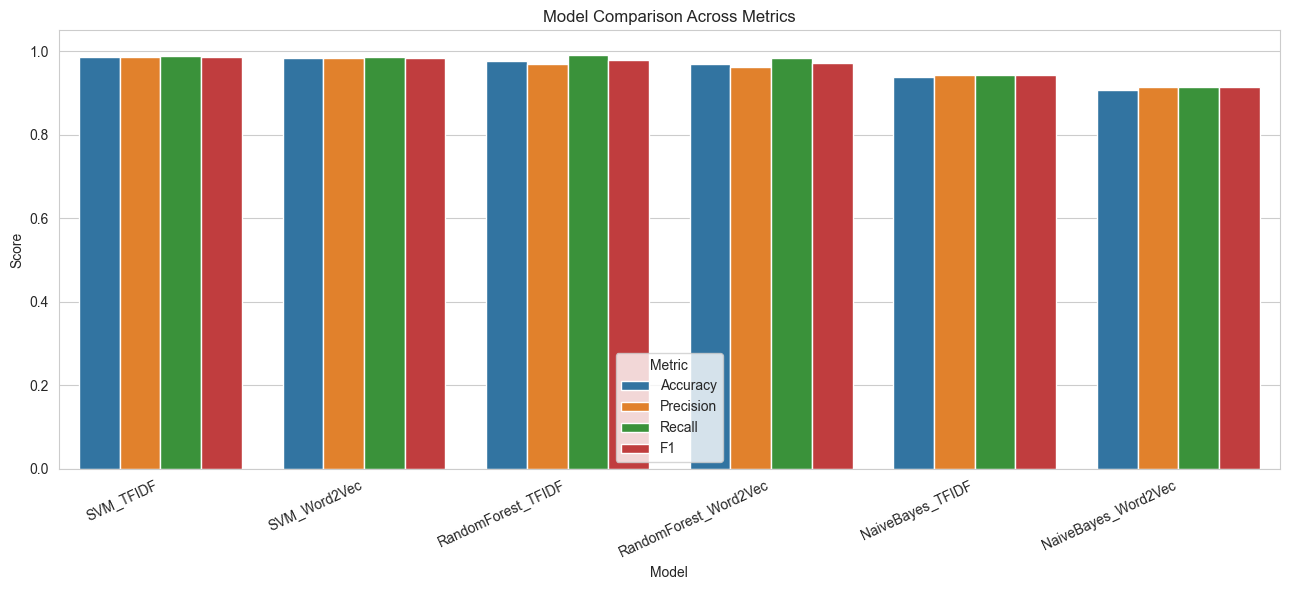

In [ ]:
plot_df = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
                           var_name='Metric', value_name='Score')

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
ax.set_title('Model Comparison Across Metrics')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../images/model_comparison_bars.png', dpi=150)
plt.show()


### Confusion Matrices

**How to read these:** each heatmap's diagonal (top-left to bottom-right) is correct predictions; the off-diagonal cells are the two error types — false positives (real news predicted as fake) in the top-right, false negatives (fake news predicted as real) in the bottom-left, given a `[Fake, Real]` label order. A model with a heavier bottom-left cell is letting more fake news through undetected; a heavier top-right cell is more aggressively flagging real news as fake.

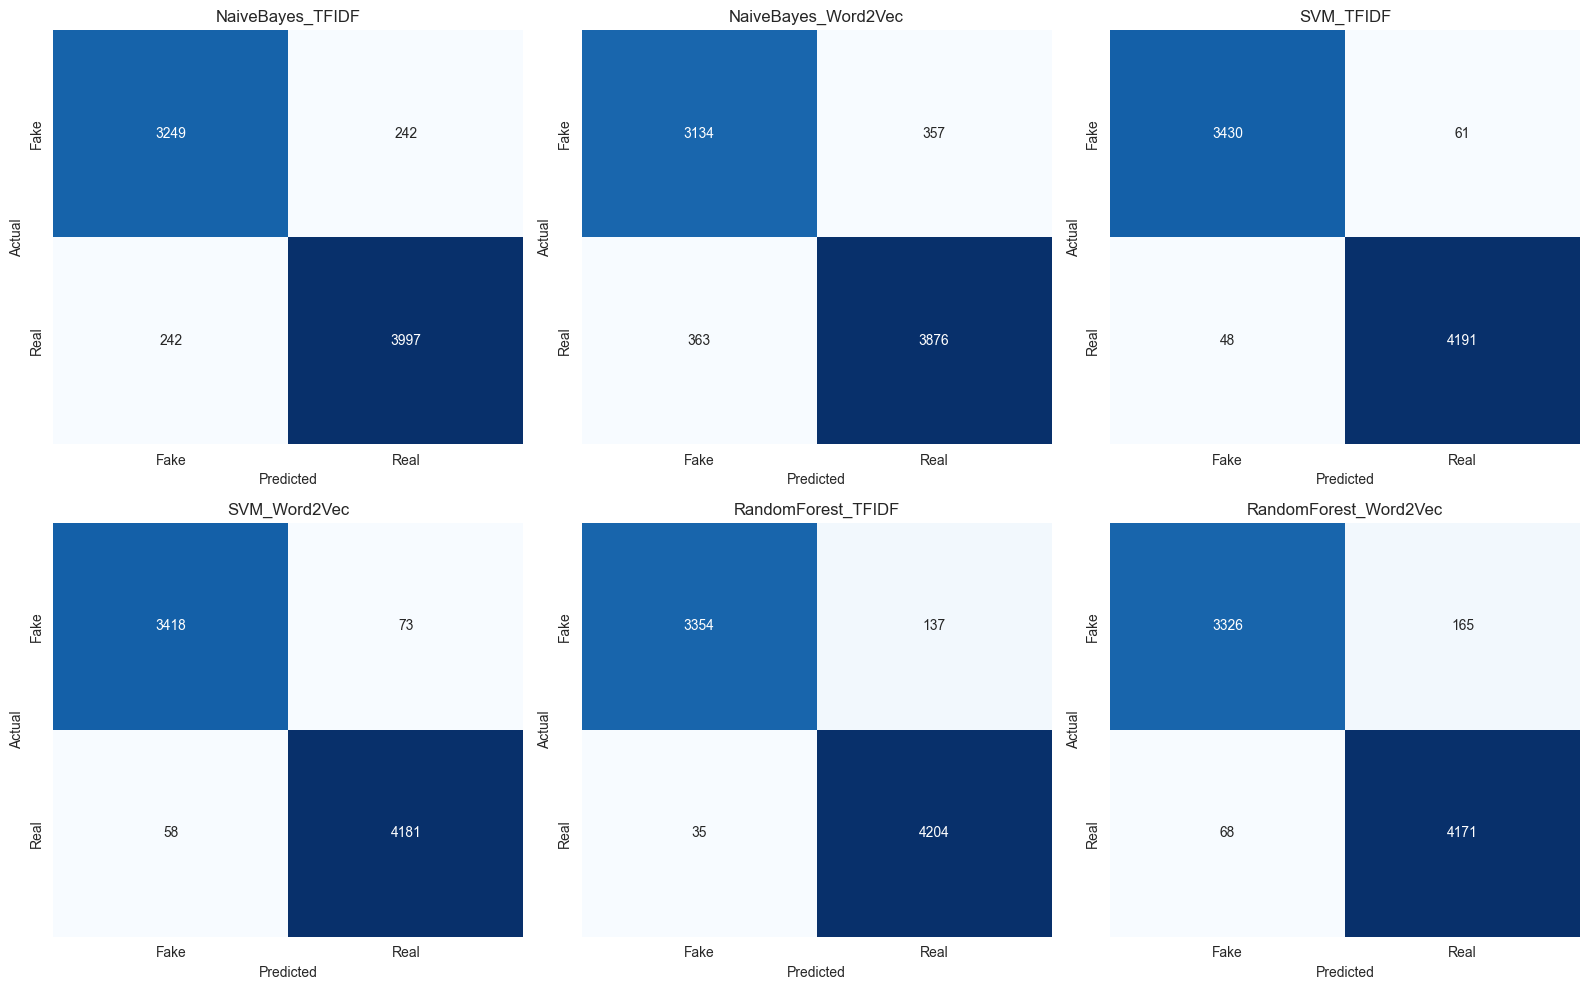

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'], cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../images/confusion_matrices.png', dpi=150)
plt.show()


## ROC Curves

**Why we do this:** the ROC curve plots true positive rate against false positive rate across every possible decision threshold, rather than just the default 0.5 cutoff — it summarizes a model's discriminative ability independent of any single threshold choice. The Area Under the Curve (AUC) condenses this into one number: 1.0 is a perfect classifier, 0.5 is no better than random guessing.

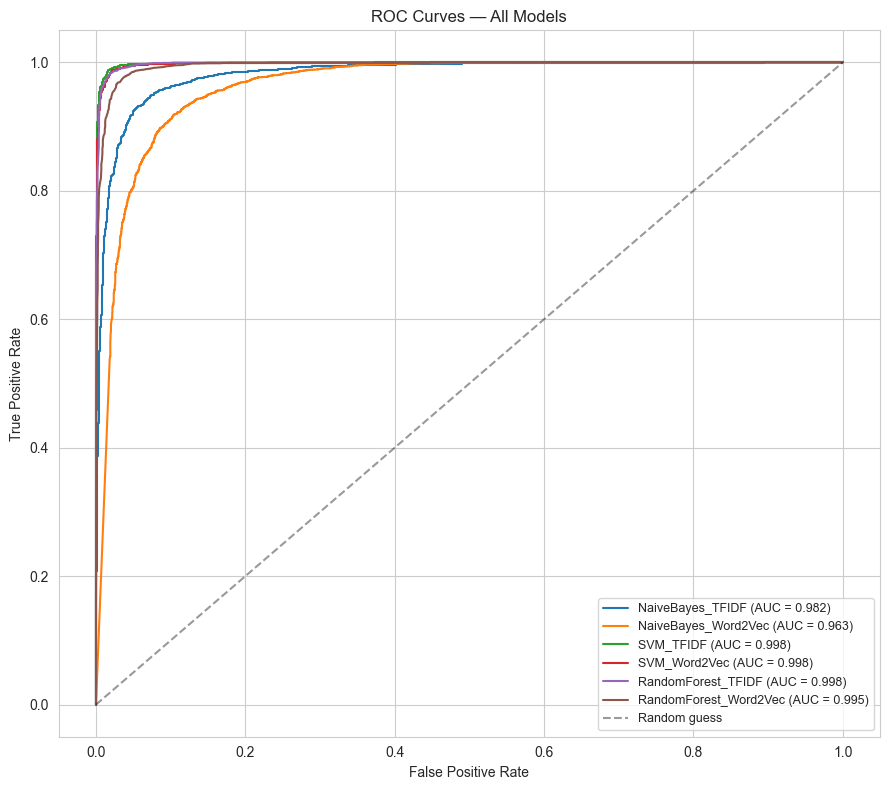

In [ ]:
plt.figure(figsize=(9, 8))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../images/roc_curves.png', dpi=150)
plt.show()


## Full Classification Report — Top Model

**Why we do this:** the summary table above shows overall precision/recall/F1, but a full `classification_report` breaks these out per class, which matters if the model performs noticeably differently on real vs. fake articles specifically.

In [ ]:
best_model_name = results_df.iloc[0]['Model']
print(f"Full classification report for the top-ranked model: {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name], target_names=['Fake', 'Real']))


Full classification report for the top-ranked model: SVM_TFIDF

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      3491
        Real       0.99      0.99      0.99      4239

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



## Recommending the Best Model

**Reasoning approach:** rather than picking a model by eye, the recommendation below is driven directly by the computed metrics — F1-score as the primary ranking criterion (since it balances precision and recall, and this project has no stated reason to prefer one over the other), with ROC-AUC and training time as tie-breaking context. Re-run this cell after real data has populated `results_df` to get the actual, data-driven recommendation for this project.

In [ ]:
top = results_df.iloc[0]
runner_up = results_df.iloc[1]

print("MODEL RECOMMENDATION")
print("=" * 60)
print(f"Best model by F1-score: {top['Model']}")
print(f"  Accuracy:  {top['Accuracy']:.4f}")
print(f"  Precision: {top['Precision']:.4f}")
print(f"  Recall:    {top['Recall']:.4f}")
print(f"  F1-score:  {top['F1']:.4f}")
print(f"  ROC-AUC:   {top['ROC_AUC']:.4f}")
print()
print(f"Runner-up: {runner_up['Model']} (F1 = {runner_up['F1']:.4f}, "
      f"a gap of {top['F1'] - runner_up['F1']:.4f})")
print()
if top['F1'] - runner_up['F1'] < 0.01:
    print("Note: the gap to the runner-up is small (<0.01 F1) — consider training time, "
          "interpretability, and inference speed as additional deciding factors before "
          "committing to this model for deployment .")


MODEL RECOMMENDATION
Best model by F1-score: SVM_TFIDF
  Accuracy:  0.9859
  Precision: 0.9857
  Recall:    0.9887
  F1-score:  0.9872
  ROC-AUC:   0.9981

Runner-up: SVM_Word2Vec (F1 = 0.9846, a gap of 0.0026)

Note: the gap to the runner-up is small (<0.01 F1) — consider training time, interpretability, and inference speed as additional deciding factors before committing to this model for deployment .




- **Common mistake:** ranking models by accuracy alone — on a dataset with even mild imbalance, a model can post high accuracy while performing poorly on one class specifically; F1 (or a class-specific recall, if false negatives are especially costly) is a more robust primary criterion.
- **Common mistake:** picking the best model purely from the metrics table without glancing at its confusion matrix — two models can have similar F1 scores while making very different *kinds* of errors, which matters for a real deployment decision.
- **Best practice:** treat a sub-0.01 F1 gap between the top two models as a tie, and let secondary factors — training time, model size, interpretability — break it, rather than over-reading noise as a meaningful difference.
- **Best practice:** keep the ROC/AUC view alongside F1 — F1 is threshold-dependent (default 0.5 cutoff), while AUC evaluates ranking quality across all thresholds, and the two can occasionally disagree on which model is "better," which is itself worth reporting.

## Summary

- Computed accuracy, precision, recall, F1, and ROC-AUC for all six trained models
- Visualized results with a grouped bar chart, a full grid of confusion matrices, and combined ROC curves
- Printed a full per-class classification report for the top-ranked model
- Produced a data-driven best-model recommendation based on F1-score, with a built-in check for a statistical near-tie
- The selected model and its vectorizer are saved and packaged for deployment in Phase 12
